# ARCHIVE: Scratchpad

This notebook contains exploratory, scratchpad code that was originally in `KL2.ipynb` below the `# Scratchpad` heading. **This code was not used in the final analysis** and is archived here for reference only.

Moved from `KL2.ipynb` on 2026-05-01.

# Scratchpad

In [ ]:
# showing how the uncertainty metric works
X = np.array([11, 12, 13, 16, 17, 18, 19, 20, 21])
bw_base = 0.9*np.std(X)*len(X)**-0.2
xplot = np.linspace(np.min(X)-3*bw_base, np.max(X)+3*bw_base, 1_001)
ytotals1 = []
ytotals2 = []

for _ in range(1000):
    W = np.random.dirichlet(np.ones_like(X))
    yi = norm.pdf(xplot.reshape(-1,1), X, bw_base)*W
    ytotals1.append(yi.sum(axis=1))
    
    W = np.random.dirichlet(np.ones_like(X)*10)
    yi = norm.pdf(xplot.reshape(-1,1), X, bw_base)*W
    ytotals2.append(yi.sum(axis=1))

ytotals1 = np.array(ytotals1)
ytotals2 = np.array(ytotals2)

In [ ]:
# showing how the uncertainty metric works
fig, axes = plt.subplots(2,1, figsize=(6,4))

for i, yplot in enumerate([ytotals1.T, ytotals2.T]):
    ax = axes[i]
    qlo = np.quantile(yplot, 0.25, axis=1)
    qhi = np.quantile(yplot, 0.75, axis=1)
    ax.plot(xplot, yplot, linewidth=0.01, color='black');
    ax.plot(xplot, yplot.mean(axis=1), linewidth=2, color='black')
    ax.plot(xplot, qlo, color='tab:red', linestyle='--')
    ax.plot(xplot, qhi, color='tab:red', linestyle='--')
    ax.fill_between(xplot, qlo, qhi, color='tab:red', alpha=0.5)
    
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_xticks([])
    ax.set_ylim(0,)
    
    area_iqr = np.round(np.trapz(qhi, xplot) - np.trapz(qlo, xplot), 3)
    ax.text(1,1,f'Uncertainty Metric = {area_iqr}', ha='right', va='top', transform=ax.transAxes)
    

In [ ]:
# xplot1, yplot1, dict_analytics1 = kl2(data=X, xplot=xplot, evtargets=[13])
# xplot2, yplot2, dict_analytics2 = kl2(data=X, xplot=xplot, evtargets=np.random.uniform(10,30,100))

# fig, axes = plt.subplots(2,1)

# ax = axes[0]
# kl2_plot(xplot1, yplot1, ax)

# ax = axes[1]
# kl2_plot(xplot2, yplot2, ax)

# Playing with the Dirichlet distribution

In [ ]:
maxes = [1, 10, 100, 1000]
n = 10_000
allx = []
ally = []
fig, axes = plt.subplots(len(maxes),1, sharey=True, gridspec_kw=dict(hspace=0.5))
for i, xmax in enumerate(maxes):
    ax = axes[i]
    xplot = []
    yplot = []
    for _ in range(10000):
        x = np.random.uniform(0,xmax,10)
        y = np.random.dirichlet(x)
        xplot += list(x)
        yplot += list(y)

    if i == 0:
        allx += xplot
    ax.scatter(xplot, yplot, s=0.001)
    ax.set_ylim(0,)
    ax.get_yaxis().set_visible(False)
    
fig.suptitle('Exploring the effect of alpha on the Dirichlet distribution')

In [ ]:
sizes = [3, 5, 10, 25]

fig, axes = plt.subplots(len(sizes),1)

for i, size in enumerate(sizes):
    ax = axes[i]
    xplot = np.arange(1,size+1)/size
    yplot = []
    for _ in range(1000):
        yplot.append(np.random.dirichlet(xplot))
    yplot = np.array(yplot)

    sns.boxplot(yplot, color='white', fliersize=0, ax=ax)
    sns.stripplot(yplot, s=1, ax=ax)
    ax.set_xticklabels(xplot, fontsize=6)

fig.suptitle('How does likelihood change with bigger alpha, normalized to one?')

In [ ]:
xplots = [[0.25,0.5,0.75,1],[0.2,0.4,0.6,1],[0.1,0.2,0.3,1],[0.01,0.02,0.03,1]]

fig, axes = plt.subplots(len(xplots),1)

for i, xplot in enumerate(xplots):
    ax = axes[i]
    yplot = []
    for _ in range(1000):
        yplot.append(np.random.dirichlet(xplot))
    yplot = np.array(yplot)

    sns.boxplot(yplot, color='white', fliersize=0, ax=ax)
    sns.stripplot(yplot, s=1, ax=ax)
    ax.set_xticklabels(xplot, fontsize=6)

fig.suptitle("What if there's one alpha that's much higher than the others?")

# Compare KDE2 with DPGMM

# Demonstrating that the mean of a distribution is the same as selecting randomly

In [ ]:
#how to pull random samples from a PDF represented by X and Y values
def random_samples(X, Y, n=1):
    pdf = Y/scipy.integrate.trapezoid(Y, X)
    cdf = np.cumsum(pdf) * np.diff(X, prepend=X[0])
    inverse_cdf = scipy.interpolate.interp1d(cdf, X, kind='linear', fill_value="extrapolate")
    return inverse_cdf(np.random.uniform(0,1,n))


fig, ax = plt.subplots()
ax.plot(xplot, yplot[0])
ax.hist(random_samples(xplot, yplot[0], n=10_000), density=True, bins=50);

In [ ]:
# demonstrating that the mean yplot best reflects randomly sampling a distribution then randomly sampling from that distribution

fig, ax = plt.subplots()

# real samples
samples = []
for _ in range(100_000):
    i = random.randint(0,yplot.shape[0]-1)
    samples.append(random_samples(xplot, yplot[i], n=1))
samples = np.array(samples).flatten()
ax.hist(samples, bins=100, density=True, label='true data');

#by median
q50 = np.quantile(yplot, 0.50, axis=0)
q50 /= scipy.integrate.trapezoid(q50, xplot)
ax.plot(xplot, q50, label='median');

#by mean
means = np.mean(yplot, axis=0)
print(scipy.integrate.trapezoid(means, xplot))
means /= scipy.integrate.trapezoid(means, xplot)
print(scipy.integrate.trapezoid(means, xplot))
ax.plot(xplot, means, label='mean');

ax.legend()

# Old Scenario 2.1 and 2.2 with alpha=ones and alpha=fours and checking similarity of results

In [ ]:
# OLD SCENARIO 2.1 and 2.2 with alpha=ones and alpha=fours


X = np.array([11, 12, 13, 16, 17, 18, 19, 20, 21])
BW_factors = np.array([0.88247698, 1.05838405, 1.08353463, 0.99264064, 0.98733438,
       0.89708815, 0.91940053, 1.04995333, 1.12918731])
BW_factors = BW_factors / np.mean(BW_factors)
alpha = np.ones_like(X)
W = alpha/np.sum(alpha)
bw_base = weighted_bw(X, W, bw_method='silverman')
BW = BW_factors*bw_base
std_base = weighted_std(X, W)
xplot = np.linspace(min(X)-std_base*3, max(X)+std_base*3, 1_001)
colors = sns.color_palette('tab10', len(X))

nrows = 2
ncols = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(12,4),
                         gridspec_kw=dict(hspace=0.75, wspace=0.1))
ytitle = 1.2
nruns = 1_000
lw = 0.01

alpha_aiqr = 1.0

####################### TOP LEFT PLOT ######################################################
ax = axes[0,0]

Ws = []
Y = []
# run analysis
for _ in range(nruns):
    Wrun = np.random.dirichlet(alpha)
    Ws.append(Wrun)
    ytotal = np.zeros_like(xplot)
    BW = bw_dirichlet(X, alpha, BW_factors, Wrun, bw_method='silverman')
    for x, w, bw, color in zip(X, Wrun, BW, colors):
        yplot = norm.pdf(xplot, x, bw)*w
        ytotal += yplot
        ax.plot(xplot, yplot, linestyle='-', linewidth=lw, color=color)
        if _==0:
            ax.scatter(x, -0.01, marker='|', color=color, s=50)
    ytotal /= np.trapz(ytotal, xplot)
    ax.plot(xplot, ytotal, linestyle='-', linewidth=lw, color='black')
    Y.append(ytotal)

# format arrays and save results
Y = np.array(Y)
Ws = np.array(Ws)
yplot_s21 = Y

# plot A_IQR
qlo = np.quantile(Y, 0.25, axis=0)
qhi = np.quantile(Y, 0.75, axis=0)
ax.fill_between(xplot, qlo, qhi, color='tab:red', alpha=alpha_aiqr, label=f'A{loiqr}')
print('A_IQR')
print(np.trapz(qhi, xplot) - np.trapz(qlo, xplot))
print('')

# plot mean resulting PDF
ax.plot(xplot, np.mean(Y, axis=0), linestyle='-', linewidth=2, color='black', label='Mean Resulting PDF')

#format
ax.text(x=0, y=ytitle, s=r"$\bf{ (a) }$" + f' Resulting PDFs when all α={int(alpha[0])}', ha='left', va='top', fontsize=10, transform=ax.transAxes)
ax.legend(loc='upper left', bbox_to_anchor=(0,1), fontsize=8)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set_xticks([]);
ax.set_xlabel(f'Embodied Carbon Coefficient (kgCO{lo2}e/unit)')

# ytmin, ytmax = ax.get_ylim()
ax.set_ylim(0, 0.2)


####################### BOTTOM LEFT PLOT ######################################################
ax = axes[1,0]

#plot
sns.stripplot(Ws, ax=ax, size=0.5)
ax.scatter(np.arange(len(alpha)), alpha/sum(alpha), marker='_', s=200, color=colors)

#add labels to each strip plot
for x, y, s, c in zip(np.arange(len(alpha)), alpha/sum(alpha), alpha, colors):
    ax.text(x=x-0.2, y=y, s=s, color=c, ha='right', va='bottom', fontsize=6)
    ax.text(x=x-0.2, y=y, s=f'{np.round(s/sum(alpha)*100,1)}%', color=c, ha='right', va='top', fontsize=6)

#add label legend
y = 0.6
ax.text(x=0.2, y=y, s='α', ha='right', va='bottom', fontsize=8, transform=ax.transAxes, color='black')
ax.text(x=0.2, y=y, s='Mean Weight', ha='right', va='top', fontsize=8, transform=ax.transAxes, color='black')
ax.scatter(x=0.225, y=y, marker='_', s=200, color='black',transform=ax.transAxes)

#add BW labels

#format
# ax.set_title('(b) Sampled kernel weights based on α from (a)', loc='left')
ax.text(x=0, y=ytitle, s=r"$\bf{ (b) }$" + ' Sampled kernel weights of (a)', ha='left', va='top', fontsize=10, transform=ax.transAxes)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set_xticks([]);
ax.set_ylim(0,);
ybmin, ybmax = ax.get_ylim()


####################### TOP RIGHT PLOT ######################################################
ax = axes[0,1]

alpha = np.ones_like(X)*4
Ws = []
Y = []
for _ in range(nruns):
    Wrun = np.random.dirichlet(alpha)
    Ws.append(Wrun)
    ytotal = np.zeros_like(xplot)
    BW = bw_dirichlet(X, alpha, BW_factors, Wrun, bw_method='silverman')
    for x, w, bw, color in zip(X, Wrun, BW, colors):
        yplot = norm.pdf(xplot, x, bw)*w
        ytotal += yplot
        ax.plot(xplot, yplot, linestyle='-', linewidth=lw, color=color)
        if _==0:
            ax.scatter(x, -0.01, marker='|', color=color, s=50)
    ytotal /= np.trapz(ytotal, xplot)
    ax.plot(xplot, ytotal, linestyle='-', linewidth=lw, color='black')
    Y.append(ytotal)

# format arrays and save results
Y = np.array(Y)
Ws = np.array(Ws)
yplot_s22 = Y

# plot A_IQR
qlo = np.quantile(Y, 0.25, axis=0)
qhi = np.quantile(Y, 0.75, axis=0)
ax.fill_between(xplot, qlo, qhi, color='tab:red', alpha=alpha_aiqr, label=f'A{loiqr}')
print('A_IQR')
print(np.trapz(qhi, xplot) - np.trapz(qlo, xplot))
print('')

# plot mean resulting PDF
ax.plot(xplot, np.mean(Y, axis=0), linestyle='-', linewidth=2, color='black', label='Mean Resulting PDF')

#format
ax.text(x=0, y=ytitle, s=r"$\bf{ (c) }$" + f' Resulting PDFs when all α={int(alpha[0])}', ha='left', va='top', fontsize=10, transform=ax.transAxes)

# ax.legend(fontsize=8)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set_xticks([]);
# ax.set_xlabel('Kernel Locations')
# ax.set_ylim(ytmin, ytmax)
ax.set_ylim(0, 0.2)


####################### BOTTOM RIGHT PLOT ######################################################
ax = axes[1,1]

#plot
sns.stripplot(Ws, ax=ax, size=0.5)
ax.scatter(np.arange(len(alpha)), alpha/sum(alpha), marker='_', s=200, color=colors)

#add labels to each strip plot
for x, y, s, c in zip(np.arange(len(alpha)), alpha/sum(alpha), alpha, colors):
    ax.text(x=x-0.2, y=y, s=s, color=c, ha='right', va='bottom', fontsize=6)
    ax.text(x=x-0.2, y=y, s=f'{np.round(s/sum(alpha)*100,1)}%', color=c, ha='right', va='top', fontsize=6)

#add label legend
# y = 0.6
# ax.text(x=0.2, y=y, s='α', ha='right', va='bottom', fontsize=8, transform=ax.transAxes, color='black')
# ax.text(x=0.2, y=y, s='Mean Weight', ha='right', va='top', fontsize=8, transform=ax.transAxes, color='black')
# ax.scatter(x=0.225, y=y, marker='_', s=200, color='black',transform=ax.transAxes)

#add BW labels

#format
# ax.set_title('(b) Sampled kernel weights based on α from (a)', loc='left')
ax.text(x=0, y=ytitle, s=r"$\bf{ (d) }$" + ' Sampled kernel weights of (c)', ha='left', va='top', fontsize=10, transform=ax.transAxes)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set_xticks([]);
ax.set_ylim(ybmin, ybmax);


ax = axes[0,0]
ax.text(x=0, y=ytitle+0.15, s='Scenario 2.1', ha='left', va='bottom', fontsize=12, transform=ax.transAxes)
ax = axes[0,1]
ax.text(x=0, y=ytitle+0.15, s='Scenario 2.2', ha='left', va='bottom', fontsize=12, transform=ax.transAxes);


In [ ]:
# get results from Scenarios 2.1 and 2.2
results1 = []
results2 = []
for i in range(len(yplot_s22)):
    results1.append(effective_variance(xplot, yplot_s21[i])**0.5)
    results2.append(effective_variance(xplot, yplot_s22[i])**0.5)

fig, ax = plt.subplots(figsize=(6,2))
sns.stripplot(results1, orient='h', ax=ax, size=2, color='tab:blue')
# sns.kdeplot(results1, ax=ax, fill=True, color='tab:blue')
sns.boxplot(results1, ax=ax, orient='h', color='white', fliersize=0)

sns.stripplot(results2, orient='h', ax=ax, size=2, color='tab:orange')
# sns.kdeplot(results2, ax=ax, fill=True, color='tab:blue')
sns.boxplot(results2, ax=ax, orient='h', color='white', fliersize=0)


# double check results against manual KDE

bw_base = weighted_bw(X, alpha/sum(alpha), bw_method='silverman')
yplot_kde = np.zeros_like(xplot)
for x, w, bw_factor in zip(X, alpha/sum(alpha), BW_factors):
    yplot_kde += norm.pdf(xplot, x, bw_base*bw_factor)*w

ymin, ymax = ax.get_ylim()
ax.vlines(effective_variance(xplot, yplot_kde)**0.5, ymin, ymax, color='red')

In [ ]:

#Scenario 2.1 and 2.2 are very similar
fig, ax = plt.subplots()

#plot mean of each scenario
ax.plot(xplot, np.mean(yplot_s21, axis=0), label='S2.1', linewidth=2, linestyle='--', color='tab:orange')
ax.plot(xplot, np.mean(yplot_s22, axis=0), label='S2.2', linewidth=2, linestyle='-.', color='tab:green')

#plot all runs from each scenario
ax.plot(xplot, yplot_s21.T, linestyle='-', linewidth=0.01, color='tab:orange')
ax.plot(xplot, yplot_s22.T, linestyle='-', linewidth=0.01, color='tab:green')



yplot_kde = np.zeros_like(xplot)
for x, w, bw_factor in zip(X, W, BW_factors):
    yplot_kde += norm.pdf(xplot, x, bw_base*bw_factor)*w
ax.plot(xplot, yplot_kde, linewidth=2, color='tab:blue', label='manual kde')


ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set_ylim(0,)
ax.set_xticks([])
ax.legend()
ax.set_title('Test plot used to visualize difference between \n resulting PDFs of different scenarios');

print('S21 StD: ', effective_variance(xplot, np.mean(yplot_s21, axis=0))**0.5)
print('S22 StD: ', effective_variance(xplot, np.mean(yplot_s22, axis=0))**0.5)
print('KDE StD: ', effective_variance(xplot, yplot_kde)**0.5)

In [ ]:
#checking to see how to calculate the necessary bandwidth to meet a certain standard deviation
STD_data = []
STD_result = []
colors = []
BW = []
Y = []

X = np.random.uniform(10,20,5)
W = np.random.dirichlet(np.ones_like(X))
BW_factors = np.random.uniform(0.9,1.1,5)
BW_factors = BW_factors / np.mean(BW_factors)

bw_base = weighted_bw(X, W, bw_method='silverman')
std_base_result = weighted_std(X, W, BW_factors*bw_base)
std_base_data = weighted_std(X, W)
xplot = np.linspace(min(X)-10*bw_base, max(X)+10*bw_base, 1_001)

print(f'{std_base_result} - Resulting StDev w/ KDE')
print(f'{std_base_data} - StDev from Data')

for _ in range(1_000):
    # StDev weighted
    Wrun = np.random.dirichlet(np.ones(len(X)))
    std_data = weighted_std(X, Wrun)
    STD_data.append(std_data)

    # Calculate what bw_run should be
    bw_run = weighted_bw(X, Wrun, bw_method='silverman')
    std_kernel = bw_run*BW_factors
    color = 'tab:green'
    var_data = std_data**2
    var_kernel = np.sum(Wrun*std_kernel**2)
    var_result = std_base_result**2
    if  var_data + var_kernel < var_result:
        color = 'tab:blue'
        bw_run *= np.sqrt((var_result - var_data) / var_kernel)
    
    #check if the function works - it does!!
    # test = np.round(bw_dirichlet(X, W, BW_factors, Wrun)/(bw_run*BW_factors), 4)
    # if np.max(test) > 1. or np.min(test) < 1.:
    #     print(f'Inequality: {bw_dirichlet(X, W, BW_factors, Wrun)} != {bw_run*BW_factors}')
    
    # Run KDE numerically to check if it worked
    ytotal = np.zeros_like(xplot)
    for x, w, bw_factor in zip(X, Wrun, BW_factors):
        ytotal += norm.pdf(xplot, x, bw_run*bw_factor)*w
    std_result = weighted_std(xplot, ytotal)
    STD_result.append(std_result)
    colors.append(color)
    Y.append(ytotal)
    BW.append(np.sqrt(np.sum(Wrun*(bw_run*BW_factors)**2)))

fig, axes = plt.subplots(2, 2, figsize=(6,6), gridspec_kw=dict(hspace=0.25))
################################################################################################
################################################################################################

ax = axes[0,0]
ax.set_title('NUMERICAL: std_data vs std_result', fontsize=8)
ax.scatter(STD_data, STD_result, c=list(colors), s=0.1)
ax.set_xlabel('StDev Run')
ax.set_ylabel('StDev KDE')

ax.set_ylim(0,)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

ax.hlines(std_base_result, xmin, xmax, linestyle=':', color='gray')
ax.text(x=xmax, y=std_base_result, s='StDev Base (KDE)', va='top', ha='right', color='gray')

# ax.vlines(weighted_std(X, W), ymin, ymax, color='gray')
# ax.text(x=weighted_std(X, W), y=ymin, s='StDev Base (Weights)', va='bottom', ha='left', color='gray');

if ymax < std_base_result:
    ax.set_ylim(0, std_base_result*1.5)

################################################################################################
################################################################################################

ax = axes[0,1]
ax.set_title('Error: (Alg-Num)/Max', fontsize=8)
alg = np.sqrt(np.array(STD_data)**2 + np.array(BW)**2)
num = np.array(STD_result)
diff = (alg-num)/np.max([alg, num])
ax.scatter(np.array(STD_data), diff, s=0.1, color='purple')

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

ax.hlines(0, xmin, xmax, linestyle='-', color='black')
ax.text(xmin, ymax, 'Positive means Alg > Num', ha='left', va='top', fontsize=6)

################################################################################################
################################################################################################
ax = axes[1,0]
ax.set_title('ANALYTICAL: std_data vs std_result', fontsize=8)
ax.scatter(STD_data, alg, c=list(colors), s=0.1)
ax.set_xlabel('StDev Run')
ax.set_ylabel('StDev KDE')

ax.set_ylim(0,np.max(alg)*1.2)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()

ax.hlines(std_base_result, xmin, xmax, linestyle=':', color='gray')
ax.text(x=xmax, y=std_base_result, s='StDev Base (KDE)', va='top', ha='right', color='gray')

################################################################################################
################################################################################################
ax = axes[1,1]

Y = np.array(Y)
ax.plot(xplot, Y.T, color='black', linewidth=1, alpha=0.01);
ax.plot(xplot, Y.mean(axis=0), color='red');
ax.set_ylim(0, np.max(Y.mean(axis=0))*1.5)

In [ ]:
#double checking that algebraically and numerically calculating StDev of a plot get the same answer
for _ in range(10):

    X = np.random.uniform(10,15,5)
    W = np.random.dirichlet(np.ones(len(X)))

    mean = np.sum(X*W)
    var = np.sum(W * (X-mean)**2)
    std_base = weighted_std(X, W)
    iqr_base = weighted_quantile(X, W, 0.75, 'perc2val') - weighted_quantile(X, W, 0.25, 'perc2val')
    bw = weighted_bw(X, W, bw_method='silverman')
    std_alg = np.sqrt(var + bw**2)

    # print(f'{std_alg} - Algebraically calculated Standard Deviation')

    xplot = np.linspace(min(X)-5*bw, max(X)+5*bw, 10_001)
    yplot = np.zeros_like(xplot)
    for x, w in zip(X, W):
        yplot += norm.pdf(xplot, x, bw)*w

    std_num = weighted_std(xplot, yplot)
    # print(f'{std_num} - Numerically calculated Standard Deviation')
    
    print(std_alg/std_num)
    # if math.isnan(std_num):
    #     print(bw)
    #     print(X)
    #     print(W)
    #     print('')

In [ ]:
# visualizing when standard deviation is greater than the mean
fig = plt.figure(figsize=(6,3))
ax = fig.add_subplot(1,1,1, projection='ternary')
t0, l0, r0 = np.random.dirichlet(np.ones(3), size=10_000).T
# stds = np.array([t0, l0, r0]).std(axis=0)

vals = np.array([10, 20, 200], ndmin=2)

W = np.array([t0, l0, r0]).T
X = np.repeat(vals, len(W), axis=0)
means = np.array(np.sum(X*W, axis=1), ndmin=2).T
stds = np.sqrt(np.sum(W*(X-means)**2, axis=1))

ax.set_tlabel(vals.flatten()[0])
ax.set_llabel(vals.flatten()[1])
ax.set_rlabel(vals.flatten()[2])

pc = ax.scatter(t0, l0, r0, s=1, alpha=1, marker='.', c=stds)

cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
colorbar = fig.colorbar(pc, cax=cax)
colorbar.set_label("Standard Deviation", rotation=270, va="baseline")

ticks = [0,1]
labels = ['0', '1']
fontsize = 6
ax.taxis.set_ticks(ticks, labels=labels, fontsize=fontsize)
ax.laxis.set_ticks(ticks, labels=labels, fontsize=fontsize)
ax.raxis.set_ticks(ticks, labels=labels, fontsize=fontsize)

print(np.std(vals))

---

# ARCHIVE: SANDBOX

The cells below were originally under the `# SANDBOX` heading in `KL2.ipynb`. **This code was not used in the final analysis** and is archived here for reference only.

Moved from `KL2.ipynb` on 2026-05-01.

# SANDBOX

## Testing different methods of BW. var_dirichlet > var_original, always bw_base, recalculate bw with each new W

Takeaway - best to use a baseline bandwidth. There's reasoning to use the Dirichlet method, but it's needlessly complicated

In [ ]:
# var_dirichlet > var_original
xplot = np.linspace(0,30,1_001)
X = np.array([11, 12, 13, 16, 17, 18, 19, 20, 21])
alpha = np.ones_like(X)
BW_factors = np.ones_like(X)

alpha = np.random.uniform(1,5,len(X))
alpha = alpha / np.min(alpha)

BW_factors = np.random.uniform(0.9,1.1,len(X))
BW_factors = BW_factors / np.mean(BW_factors)

print('alpha')
print(alpha)
print('')
print('BW_factors')
print(BW_factors)
bw_base = weighted_bw(X, alpha / np.sum(alpha), bw_method='silverman')
ytotals = [[],[],[]]

# run all three analyses
for _ in range(250):
    W = np.random.dirichlet(np.ones(len(X)))
    bw_basenew = weighted_bw(X, W, bw_method='silverman')
    
    BW_dir = bw_dirichlet(X, alpha, BW_factors, Wrun=W, bw_method='silverman')
    BW_base = BW_factors / np.mean(BW_factors) * bw_base
    BW_dyn = BW_factors / np.mean(BW_factors) * bw_basenew
    
    for i, BW in enumerate([BW_dir, BW_base, BW_dyn]):
        # create each PDF and ensure it's valid and sums to 1
        yi = norm.pdf(xplot.reshape(-1,1), X, BW)*W
        # yplot[run] = sum(yi.T)
        yplot = yi.sum(axis=1)
        yplot /= np.trapz(yplot, xplot)

        ytotals[i].append(yplot)

# plot all three versions
titles = ['dirichlet', 'base BW', 'dynamic base BW']
fig, axes = plt.subplots(len(ytotals), 1, figsize=(6,6), gridspec_kw=dict(hspace=0.5), sharex=True)
for i, ytotal in enumerate(ytotals):
    ax = axes[i]
    ytotal = np.array(ytotal).T
    ax.plot(xplot, ytotal, linewidth=0.1, color='black');
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_title(titles[i])
    ax.set_ylim(0,)


## Getting all EPDs by year

In [ ]:
# #look at all files and only pull the most recent for each type of analysis 
# import os
# filepath = '../EPDsFromEC3/EPD_Output'
# files = [f'{filepath}/{ele}' for ele in os.listdir(filepath) if ele.startswith('EPDs_')]
# # files.sort()
# # dft = pd.DataFrame([ele[:-5].split('_')[-2:] for ele in files], columns=['material', 'date'])
# # dft['date'] = pd.to_datetime(dft['date'])
# # dft['file'] = files
# # dft = dft.sort_values('date', ascending=False)
# # lst = list(dft['material'].unique())
# # lst.sort()
# # lst

# dates = []
# uuids = []
# files.sort()
# files = [ele for ele in files if ele.find('_concrete_') == -1]
# feat1 = 'date_of_issue'
# feat2 = 'open_xpd_uuid'
# for file in files:
#     print(file, ' - ', len(dates),'/',len(uuids))
#     dft = pd.read_excel(file)
#     if feat1 in dft.columns and feat2 in dft.columns:
#         dft = dft[[feat1, feat2]]
#         dates += list(dft.dropna()['date_of_issue'].values)
#         uuids += list(dft.dropna()['open_xpd_uuid'].values)  

# dft = pd.DataFrame({'date':dates, 'uuid':uuids})
# dft = dft.drop_duplicates(subset=['uuid'])
# dft['year'] = dft['date'].str[:4]
# dft['year'].value_counts().sort_index()

# # year
# # 2011        1
# # 2012        2
# # 2013       10
# # 2014        7
# # 2015       74
# # 2016       54
# # 2017       48
# # 2018       84
# # 2019     4204
# # 2020     3241
# # 2021    24694
# # 2022    16713
# # 2023    16321
# # 2024     1485

## Visualizing stick-breaking

In [ ]:
# Visualize stick-breaking
alphas = (1,1,1)
results = []
for _ in range(50):
    results.append(np.random.dirichlet(alphas))
results = np.array(results)

fig, ax = plt.subplots()

pd.DataFrame(results).plot(kind='barh', stacked=True, ax=ax, width=0.8)
ax.get_legend().set_visible(False)
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0,1)

In [ ]:
# Visualize stick-breaking
alphas = np.ones(10)
results = []
for _ in range(50):
    results.append(np.random.dirichlet(alphas))
results = np.array(results)

fig, ax = plt.subplots()

pd.DataFrame(results).plot(kind='barh', stacked=True, ax=ax, width=0.8)
ax.get_legend().set_visible(False)
ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0,1)

##  Demonstrating Dirichlet method

In [ ]:
X = np.array([11, 12, 13, 16, 17, 18, 19, 20, 21])
bw = np.std(X)*len(X)**-0.2
xplot = np.linspace(1,30,1001)

fig, ax = plt.subplots()
for _ in range(1000):
    yi = np.zeros_like(xplot)
    # W = 0.05 + np.random.dirichlet(np.ones_like(X))*0.55
    W = np.random.dirichlet(np.ones_like(X))
    yi = norm.pdf(xplot.reshape(-1,1), X, bw)*W
    ytotal = yi.sum(axis=1)
    ytotal /= np.trapz(ytotal, xplot)
    ax.plot(xplot, ytotal, linewidth=0.025, color='black')

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set_xticks([])
ax.set_ylim(0,)

In [ ]:
alpha = np.array([5,2,3,6,1,4])
# X = np.array([1,2,3,5,6,7])
X = np.arange(len(alpha))
Xstrip = np.array([[ele]*results.shape[0] for ele in X]).flatten()
yerrs = 0.5*alpha**0.5
target = 1.25
alpha_multipliers = [1, 2, 4]

fig, ax = plt.subplots(1,1, sharex=False, gridspec_kw=dict(hspace=0.7), figsize=(6,3))

#################### FIRST PLOT ####################################
ymax = 0.75
labels = [lo1, lo2, lo3]
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for offset, am in enumerate(alpha_multipliers):
        if am < 1:
            alpha = alpha**am
        else:
            alpha = alpha*am
        results = []
        for _ in range(10_000):
            wt = np.random.dirichlet(alpha)
            results.append(wt)
        results = np.array(results)
        Xstrip = np.array([[ele]*results.shape[0] for ele in X]).flatten()
        Xstrip = Xstrip*(len(alpha_multipliers)+2) + offset
        sns.stripplot(x=Xstrip, y=results.T.flatten(), ax=ax, palette='tab10', native_scale=True, s=0.25, jitter=0.05)
        
        for x, a, color in zip(set(Xstrip), alpha, sns.color_palette('tab10', len(alpha))):
            ax.text(x=x, y=ymax, s="{:.1f}".format(np.round(a,1)), color=color, ha='center', va='bottom', fontsize=10)
            # if offset==0 and x==list(set(Xstrip))[0]:
            if x==list(set(Xstrip))[0]:
                ax.text(x=x-1, y=ymax, s=f'α{labels[offset]}{locomma}{loi}=', color=color, ha='right', va='bottom', fontsize=10)
        ymax -= 0.08


ax.set_xticks(X*(len(alpha_multipliers)+2)+1, X)
ax.set_ylim(0,)
ymin, ymax = ax.get_ylim()
ax.text(x=0, y=1.2, s=f'(a) Sampled weights based on three sets of alpha', ha='left', va='bottom', transform=ax.transAxes, fontsize=12)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)

## Exploring gamma distribution

In [ ]:
#looking at how the gamma distribution ch anges at a=1, a<1, a>1
A = [0.9,1,1.1]
n = 10_000
xplot = np.linspace(1/n,5,n)

fig, ax = plt.subplots()
for a in A:
    yplot = scipy.stats.gamma.pdf(x=xplot, a=a)
    # yplot /= max(yplot)
    ax.plot(xplot,yplot, label=a)
ax.legend()
ax.set_ylim(0,2)

In [ ]:
# looking at how the gamma distribution changes at different shapes and scales
factor = 100
fig, ax = plt.subplots(figsize=(6,2))
plt.hist(np.random.gamma(shape=100, scale=1, size=100_000), bins=100, density=True, alpha=0.5, label='Regular');
plt.hist(np.random.gamma(shape=100*factor, scale=1/factor, size=100_000), bins=100, density=True, alpha=0.5, label='With Factor');
plt.legend()

---

The cells below were originally under the `## Showcasing the Dirichlet distribution with different alphas` heading in `KL2.ipynb`. **This code was not used in the final analysis** and is archived here for reference only.

Moved from `KL2.ipynb` on 2026-05-01.

## Showcasing the Dirichlet distribution with different alphas

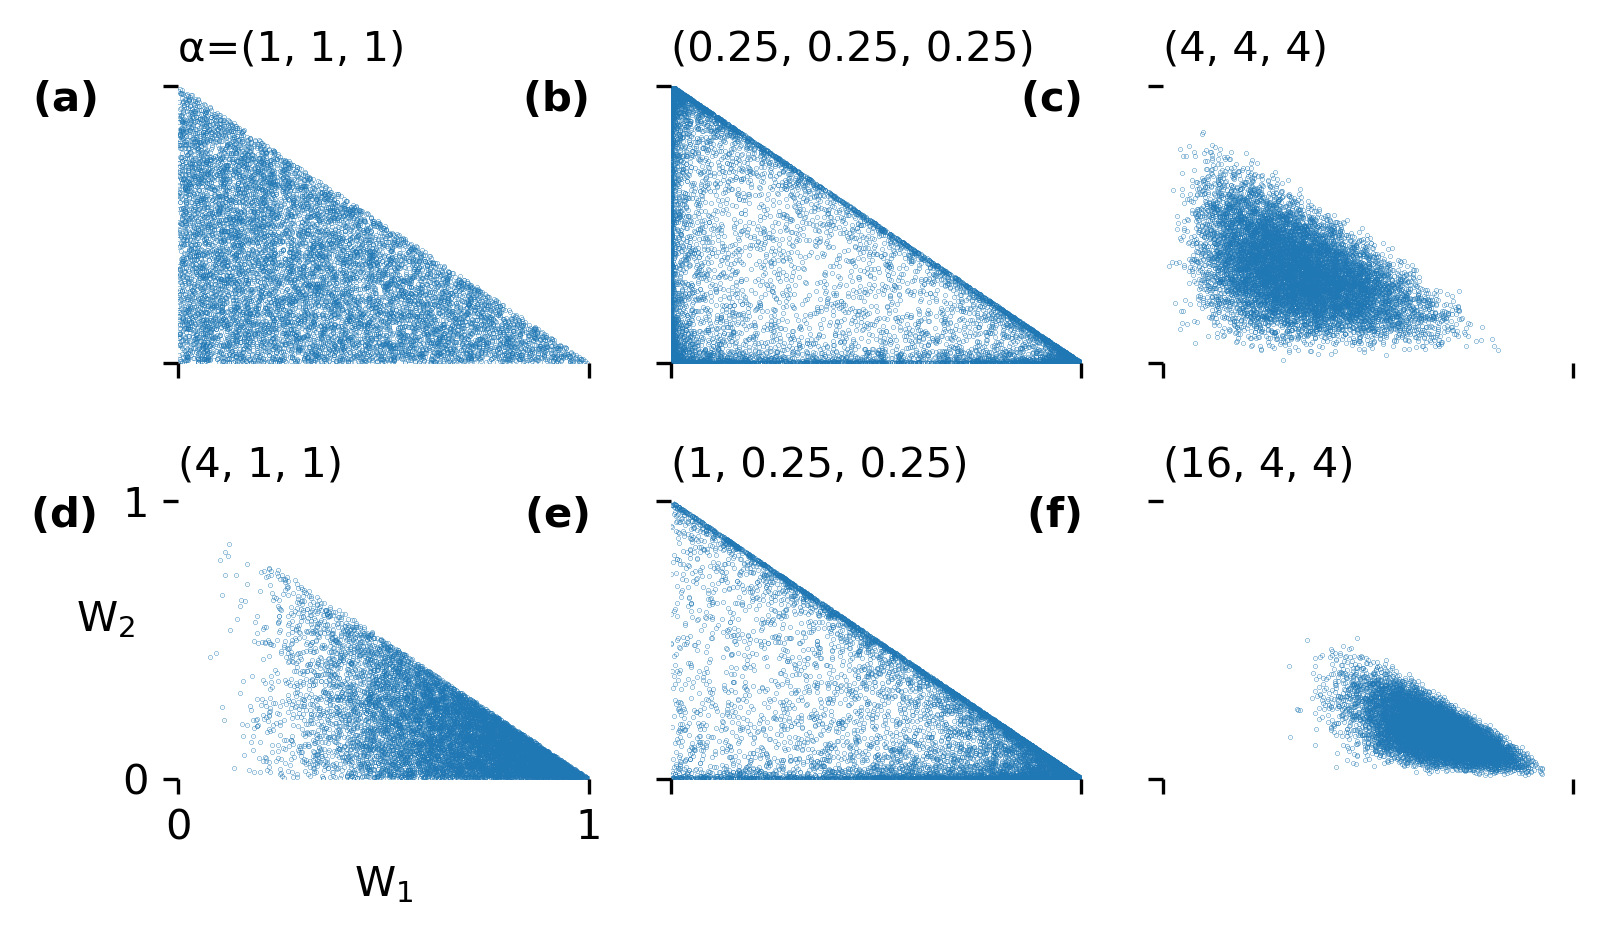

In [7]:
# Showcasing Dirichlet distribution with different alphas - triangular plot with 2/3 weights shown

alphas = [(1,1,1), (0.25,0.25,0.25), (4,4,4), (4,1,1), (1,0.25,0.25), (16,4,4)]
# alphas = [(0.2,0.05,0.05), (1,0.25,0.25), (4,1,1), [8,2,2]]
# alphas = [(5,0.5,0.5), (7.5,0.75,0.75), (10,1,1), [12,1.2,1.2]]
labels = [r"$\bf{ (a) }$",
          r"$\bf{ (b) }$",
          r"$\bf{ (c) }$",
          r"$\bf{ (d) }$",
          r"$\bf{ (e) }$",
          r"$\bf{ (f) }$",
         ]

nrows = 2
ncols = int(len(alphas)/nrows)

fig, axes = plt.subplots(nrows, ncols, figsize=(6,3), sharex=False, sharey=False, gridspec_kw=dict(hspace=0.5, wspace=0.2))

r = 0
c = 0

for alpha, label in zip(alphas, labels):
    ax = axes[r,c]
    xs = []
    ys = []
    zs = []
    for _ in range(10_000):
        x, y, z = np.random.dirichlet(alpha)
        xs.append(x)
        ys.append(y)
    ax.scatter(xs, ys, s=0.01, color='tab:blue')
    if r==0 and c==0: alpha = f'α={alpha}'
    ax.set_title(alpha, fontsize=10, loc='left')
    if r==nrows-1 and c==0:
        ax.set_xticks([0,1], [0,1])
        ax.set_yticks([0,1], [0,1])
        ax.set_xlabel(f'W{lo1}')
        ax.set_ylabel(f'W{lo2}', rotation=0)
    else:
        ax.set_xticks([0,1], [])
        ax.set_yticks([0,1], [])
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.spines[['top', 'right', 'left','bottom']].set_visible(False)
    ax.text(x=-0.20, y=0.95, s=label, ha='right', va='center', transform=ax.transAxes, fontsize=10)

    if c==ncols-1:
        r += 1
        c = 0
    else:
        c += 1

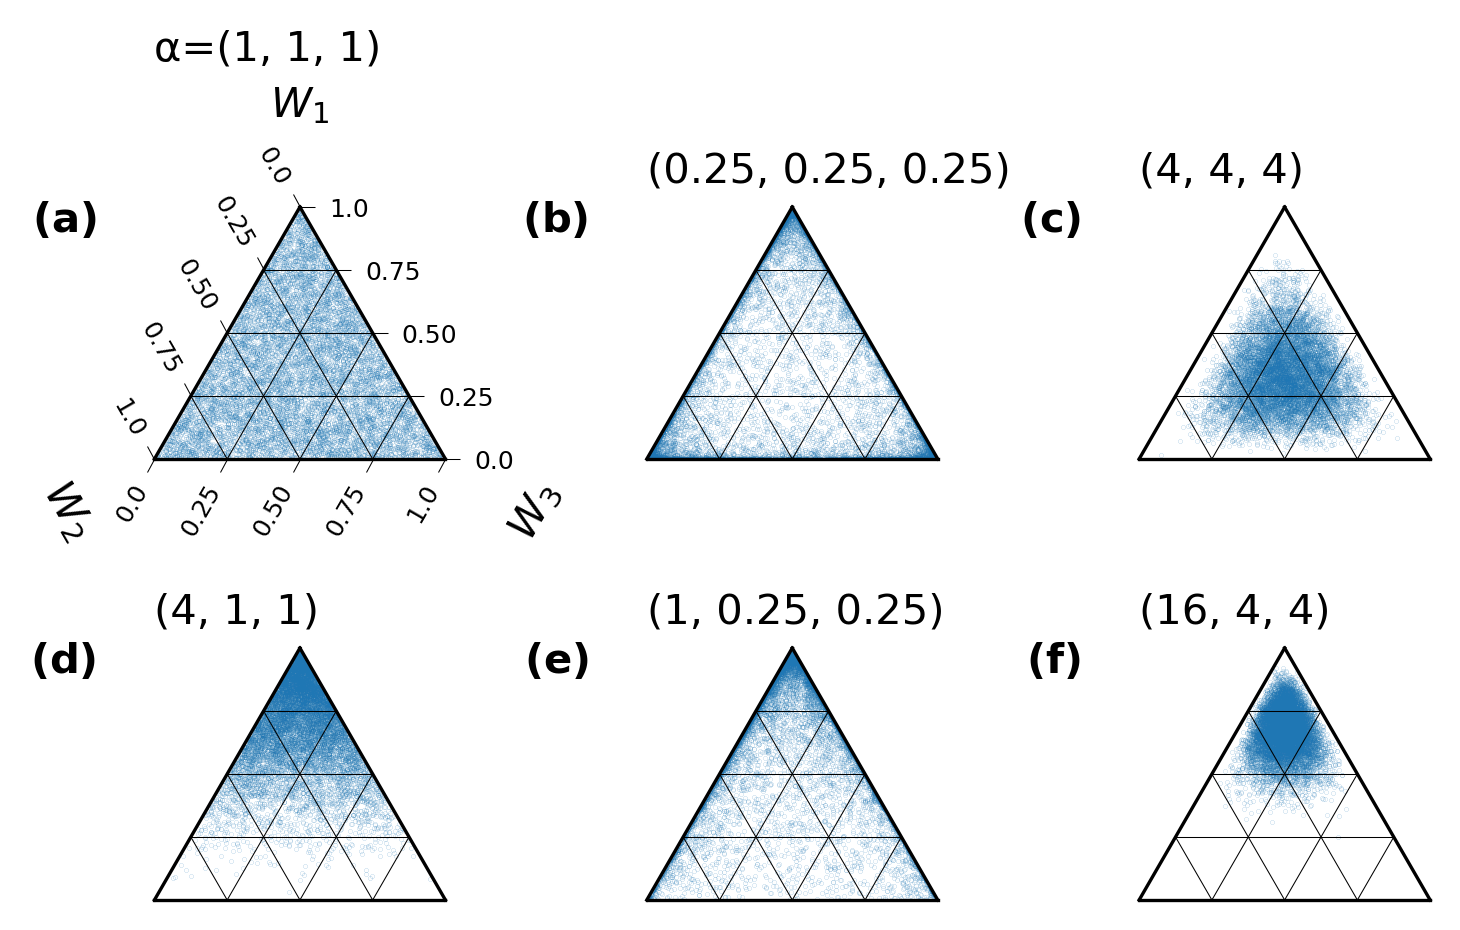

In [8]:
# Showcasing Dirichlet distribution with different alphas - barycentric/ternary plot with 3/3 weights shown
nrows = 2
ncols = 3
nplot = 0


fig = plt.figure(figsize=(6,3))
fig.subplots_adjust(left=0.075, right=0.85, wspace=0.3)

# nplot += 1
# t0, l0, r0 = np.random.dirichlet(alpha=(1.0, 1.0, 1.0), size=10_000).T
# ax = fig.add_subplot(nrows, ncols, nplot, projection="ternary")
# ax.scatter(t0, l0, r0, s=1)

alphas = [
    (1,1,1),
    (0.25, 0.25, 0.25),
    (4, 4, 4),
    (4,1,1),
    (1, 0.25, 0.25),
    (16, 4, 4),
]

labels = [r"$\bf{ (a) }$",
          r"$\bf{ (b) }$",
          r"$\bf{ (c) }$",
          r"$\bf{ (d) }$",
          r"$\bf{ (e) }$",
          r"$\bf{ (f) }$",
         ]

for alpha, label in zip(alphas, labels):
    nplot += 1
    #plot
    t0, l0, r0 = np.random.dirichlet(alpha=alpha, size=10_000).T
    ax = fig.add_subplot(nrows, ncols, nplot, projection="ternary")
    ax.scatter(t0, l0, r0, s=0.005, alpha=1, marker='.')

    #format
    ticks = [0.0, 0.25, 0.5, 0.75, 1.0]
    lw = 0.25
    if alpha == alphas[0]:
        labels = ['0.0', '0.25', '0.50', '0.75', '1.0']
        fontsize = 6
        ax.set_tlabel("$W_1$", loc='right')
        ax.set_llabel("$W_2$", loc='right')
        ax.set_rlabel("$W_3$", loc='right')
        alpha = f'α={alpha}'
        ax.taxis.set_tick_params(width=lw)
        ax.laxis.set_tick_params(width=lw)
        ax.raxis.set_tick_params(width=lw)        
        
    else:
        labels = ['', '', '', '', '']
        ax.taxis.set_tick_params(width=0.)
        ax.laxis.set_tick_params(width=0.)
        ax.raxis.set_tick_params(width=0.)
        
    ax.taxis.set_ticks(ticks, labels=labels, fontsize=fontsize)
    ax.laxis.set_ticks(ticks, labels=labels, fontsize=fontsize)
    ax.raxis.set_ticks(ticks, labels=labels, fontsize=fontsize)
    
    position = 'corner'
    # position = 'tick1'
    ax.taxis.set_label_position(position)
    ax.laxis.set_label_position(position)
    ax.raxis.set_label_position(position)
    
#     mode = 'axis'
#     ax.taxis.set_label_rotation_mode(mode)
#     ax.laxis.set_label_rotation_mode(mode)
#     ax.raxis.set_label_rotation_mode(mode)

    ax.grid(color='black', zorder=3, linewidth=lw)
    ax.set_title(alpha, fontsize=10, loc='left')
    ax.text(x=-0.20, y=0.95, s=label, ha='right', va='center', transform=ax.transAxes, fontsize=10)


plt.subplots_adjust(hspace=0.75, wspace=0.2)
plt.show()